In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

Matplotlib is building the font cache; this may take a moment.


In [4]:
#Config file
from config import setup_logger

logger = setup_logger('geology.log')
logger.info("Script started...")


# 1. Create the connection 'engine'
# Format: postgresql://[user]@localhost/[database_name]
engine = create_engine('postgresql://localhost/geo_practice')


# 3. Load the data into a Pandas DataFrame
try:    
    drillholes = pd.read_sql("SELECT * FROM drillholes", engine)
    assays = pd.read_sql("SELECT * FROM assays", engine)
    survey_grid = gpd.read_postgis("SELECT * FROM survey_grid", engine, geom_col="geometry")
    print("Success! Data loaded from SQL.")
    logger.info(f"Database connection successful. Loaded {len(drillholes)} rows.")
    logger.info(f"Database connection successful. Loaded {len(assays)} rows.")
    logger.info(f"Database connection successful. Loaded {len(survey_grid)} rows.")

    # 4. Show the first 5 rows and the column names
    print(drillholes.head())
    print(f"\nColumns found: {drillholes.columns.tolist()}")
    print(f"\nColumns found: {assays.columns.tolist()}")
    print(f"\nColumns found: {survey_grid.columns.tolist()}")

except Exception as e:
    logger.error(f"Error connecting to database: {e}")
    print(f"Error connecting to database: {e}")


Success! Data loaded from SQL.
   drillhole_id  project_id   latitude   longitude  \
0             1           2 -32.644841  151.212359   
1             2           3 -32.381339  151.698555   
2             3           3 -32.193061  151.916281   
3             4           4 -32.528713  151.510380   
4             5           2 -32.338945  151.577173   

                                            geometry  
0  0101000020E610000035836FA5CBE66240D8E4A0298A52...  
1  0101000020E61000007FAAF88E5AF662402607F2B3CF30...  
2  0101000020E61000001ABDC62C52FD624039DF2F3DB618...  
3  0101000020E6100000B7C6710755F062403C46EEDCAC43...  
4  0101000020E610000018DCDF3278F262401D35658E622B...  

Columns found: ['drillhole_id', 'project_id', 'latitude', 'longitude', 'geometry']

Columns found: ['assay_id', 'drillhole_id', 'depth_from', 'depth_to', 'copper_ppm', 'gold_ppb']

Columns found: ['cell_id', 'geometry', 'magnetic_anomaly', 'conductivity']


In [29]:
assays.columns.tolist()

['assay_id',
 'drillhole_id',
 'depth_from',
 'depth_to',
 'copper_ppm',
 'gold_ppb']

In [ ]:
# Convert drillholes to GeoDataFrame
drillholes_gdf = gpd.GeoDataFrame(
    drillholes,
    geometry=gpd.points_from_xy(drillholes.longitude, drillholes.latitude),
    crs="EPSG:4326"
)

#Bring on the assay data
drill_holes_assays_gdf = pd.merge(drillholes_gdf, assays, on="drillhole_id", how="left")

In [26]:
#create additional features for each drill hole
features = drill_holes_assays_gdf.groupby("drillhole_id").agg(
    max_copper=("copper_ppm", "max"),
    mean_copper=("copper_ppm", "mean"),
    anomaly_count=("copper_ppm", lambda x: (x > 150).sum())
).reset_index()

drill_holes_assays_gdf = pd.merge(drill_holes_assays_gdf, features, on="drillhole_id", how="left")

In [30]:
#Bring on the survey grid data using a spatial join
drill_holes_assays_gdf = gpd.sjoin(drill_holes_assays_gdf, survey_grid, how="left", predicate="intersects")

In [33]:
survey_grid

,cell_id,geometry,magnetic_anomaly,conductivity
0,G1,"POLYGON ((150.9 -31.9, 151.1 -31.9, 151.1 -32....",0.8,0.5
1,G2,"POLYGON ((151.1 -31.9, 151.3 -31.9, 151.3 -32....",1.5,0.9
2,G3,"POLYGON ((151.3 -31.9, 151.5 -31.9, 151.5 -32....",2.2,1.4
3,G4,"POLYGON ((150.9 -32.1, 151.1 -32.1, 151.1 -32....",1.0,0.6
4,G5,"POLYGON ((151.1 -32.1, 151.3 -32.1, 151.3 -32....",3.5,2.8
5,G6,"POLYGON ((151.3 -32.1, 151.5 -32.1, 151.5 -32....",2.8,2.0
6,G7,"POLYGON ((150.9 -32.3, 151.1 -32.3, 151.1 -32....",0.6,0.4
7,G8,"POLYGON ((151.1 -32.3, 151.3 -32.3, 151.3 -32....",4.0,3.2
8,G9,"POLYGON ((151.3 -32.3, 151.5 -32.3, 151.5 -32....",1.2,1.0


In [31]:
#Produce a correlation matrix for the numeric columns
corr = drill_holes_assays_gdf[["copper_ppm", "magnetic_anomaly", "conductivity"]].corr()
print(corr)

                  copper_ppm  magnetic_anomaly  conductivity
copper_ppm          1.000000         -0.012524     -0.012986
magnetic_anomaly   -0.012524          1.000000      0.993637
conductivity       -0.012986          0.993637      1.000000


In [35]:
#create a score to sort the drill holes by potential
drill_holes_assays_gdf["potential_score"] = (
    drill_holes_assays_gdf["copper_ppm"] * 0.5 +
    drill_holes_assays_gdf["magnetic_anomaly"] * 0.3 +
    drill_holes_assays_gdf["conductivity"] * 0.2
)

drill_holes_assays_gdf.sort_values("potential_score", ascending=False, inplace=True)

In [ ]:
#cut dow the drill holes to the top 10 for visualization
top_drill_holes = drill_holes_assays_gdf.head(10)

,drillhole_id,project_id,latitude,longitude,geometry,assay_id,depth_from,depth_to,copper_ppm,gold_ppb,max_copper,mean_copper,anomaly_count,index_right,cell_id,magnetic_anomaly,conductivity,potential_score
393,40,3,-32.004045,151.145692,POINT (151.14569 -32.00405),394,30.0,40.0,299.0,30.0,299.0,186.9,7,1.0,G2,1.5,0.9,150.13
739,74,4,-32.217297,151.265143,POINT (151.26514 -32.2173),740,90.0,100.0,297.0,47.0,297.0,182.6,7,4.0,G5,3.5,2.8,150.11
397,40,3,-32.004045,151.145692,POINT (151.14569 -32.00405),398,70.0,80.0,297.0,10.0,299.0,186.9,7,1.0,G2,1.5,0.9,149.13
206,21,4,-32.435654,151.490155,POINT (151.49015 -32.43565),207,60.0,70.0,297.0,2.0,297.0,218.3,7,8.0,G9,1.2,1.0,149.06
251,26,2,-32.111259,151.189560,POINT (151.18956 -32.11126),252,10.0,20.0,292.0,17.0,292.0,184.2,8,4.0,G5,3.5,2.8,147.61
205,21,4,-32.435654,151.490155,POINT (151.49015 -32.43565),206,50.0,60.0,291.0,38.0,297.0,218.3,7,8.0,G9,1.2,1.0,146.06
882,89,4,-32.175823,151.075194,POINT (151.07519 -32.17582),883,20.0,30.0,291.0,34.0,291.0,194.4,7,3.0,G4,1.0,0.6,145.92
208,21,4,-32.435654,151.490155,POINT (151.49015 -32.43565),209,80.0,90.0,290.0,3.0,297.0,218.3,7,8.0,G9,1.2,1.0,145.56
886,89,4,-32.175823,151.075194,POINT (151.07519 -32.17582),887,60.0,70.0,290.0,2.0,291.0,194.4,7,3.0,G4,1.0,0.6,145.42
197,20,3,-32.102595,151.277839,POINT (151.27784 -32.1026),198,70.0,80.0,287.0,34.0,287.0,224.6,9,4.0,G5,3.5,2.8,145.11


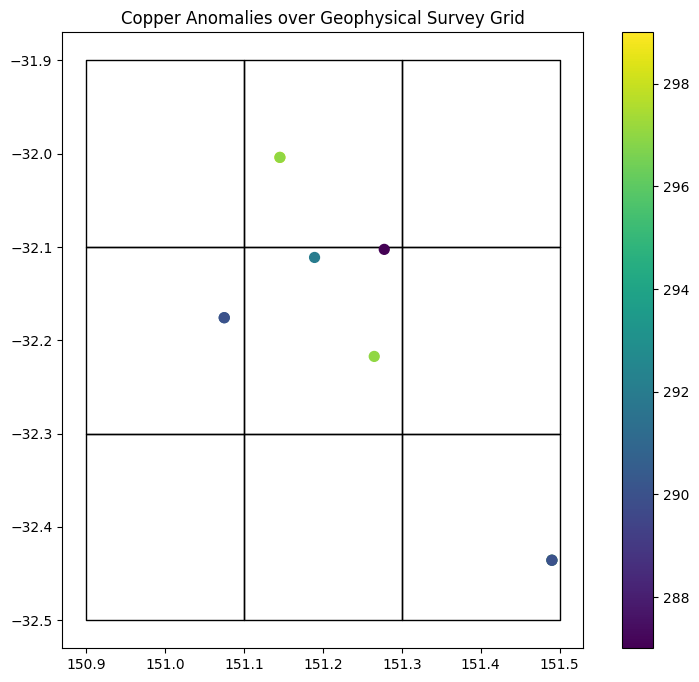

In [38]:
fig, ax = plt.subplots(figsize=(10, 8))

survey_grid.plot(ax=ax, color="none", edgecolor="black")
top_drill_holes.plot(ax=ax, column="copper_ppm", legend=True, markersize=50)

plt.title("Copper Anomalies over Geophysical Survey Grid")
plt.show()

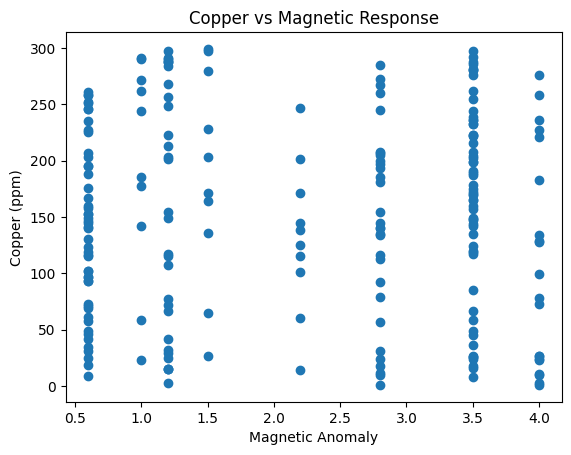

In [39]:
plt.scatter(
    drill_holes_assays_gdf["magnetic_anomaly"],
    drill_holes_assays_gdf["copper_ppm"]
)

plt.xlabel("Magnetic Anomaly")
plt.ylabel("Copper (ppm)")
plt.title("Copper vs Magnetic Response")
plt.show()